<a href="https://colab.research.google.com/github/cedrus0708/deeplearning_birdclef2024/blob/main/dl_milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIRDCLEF 2024

# Loading data

### Download and unzip data

In [1]:
import os

# for drive:
#os.chdir('/content')

# for local:
os.chdir('.')

In [2]:
# Downloading train data from Google Drive
!gdown 1zIGXRY2jlYkM0sdpum35qyi-i8SKfM_J -O "train_data.zip"

Downloading...
From (original): https://drive.google.com/uc?id=1zIGXRY2jlYkM0sdpum35qyi-i8SKfM_J
From (redirected): https://drive.google.com/uc?id=1zIGXRY2jlYkM0sdpum35qyi-i8SKfM_J&confirm=t&uuid=1b1c60ce-f83c-42e9-bd9d-50cb6586535a
To: /content/train_data.zip
100% 7.80G/7.80G [02:38<00:00, 49.3MB/s]


In [3]:
# Unzipping data
!unzip -q "/content/train_data.zip"

### Set random seed and read metadata

In [4]:
# setting seed and default imports
import numpy as np
import tensorflow as tf
import pandas as pd

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
# if true, debug messages are shown
DEBUG = False

In [6]:
# load metadata
train_metadata = pd.read_csv("train_metadata.csv")

train_metadata.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,asbfly,[],['call'],39.2297,118.1987,Muscicapa dauurica,Asian Brown Flycatcher,Matt Slaymaker,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/134896,asbfly/XC134896.ogg
1,asbfly,[],['song'],51.4030,104.6401,Muscicapa dauurica,Asian Brown Flycatcher,Magnus Hellström,Creative Commons Attribution-NonCommercial-Sha...,2.5,https://www.xeno-canto.org/164848,asbfly/XC164848.ogg
2,asbfly,[],['song'],36.3319,127.3555,Muscicapa dauurica,Asian Brown Flycatcher,Stuart Fisher,Creative Commons Attribution-NonCommercial-Sha...,2.5,https://www.xeno-canto.org/175797,asbfly/XC175797.ogg
3,asbfly,[],['call'],21.1697,70.6005,Muscicapa dauurica,Asian Brown Flycatcher,vir joshi,Creative Commons Attribution-NonCommercial-Sha...,4.0,https://www.xeno-canto.org/207738,asbfly/XC207738.ogg
4,asbfly,[],['call'],15.5442,73.7733,Muscicapa dauurica,Asian Brown Flycatcher,Albert Lastukhin & Sergei Karpeev,Creative Commons Attribution-NonCommercial-Sha...,4.0,https://www.xeno-canto.org/209218,asbfly/XC209218.ogg


# Data exploration

### Plotting label distribution across classes



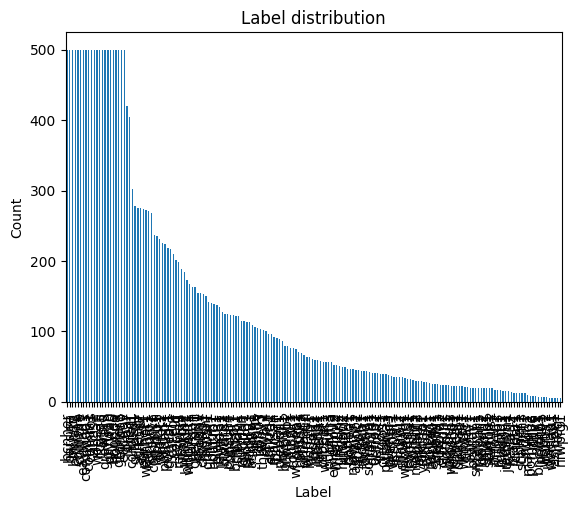

In [7]:
# Plot Label distribution
import matplotlib.pyplot as plt

if "primary_label" in train_metadata.columns:
    label_counts = train_metadata['primary_label'].value_counts()
    label_counts.plot(kind='bar')
    plt.title("Label distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.show()

## Spectograms and visualization


### Functions we need to visualize

In [8]:
import glob
import librosa
import librosa.display

def show_spectogram(S_dB_norm, filename="", fmin=0):
    # Plot
    #plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB_norm, sr=32000, x_axis='time', y_axis='mel', cmap='magma', fmin=fmin, fmax = 16000)
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Mel Spectrogram — {filename}")
    plt.tight_layout()
    plt.show()

def show_audio(filename):
    print(f"Showing spectrogram for: {filename}")
    # Load the audio
    y, sr = librosa.load(filepath, sr=None)


    # Compute mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=16000)
    S_dB = librosa.power_to_db(S, ref=np.max)

    S_dB_norm = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min()) * 2.0 - 1.0
    print(S_dB_norm.shape)
    show_spectogram(S_dB_norm, filename)

### Showing every 5000th audio file

Showing spectograms for every 5000th audio file.

Found 24459 .ogg files.
Showing spectrogram for: XC134896.ogg
(128, 1710)


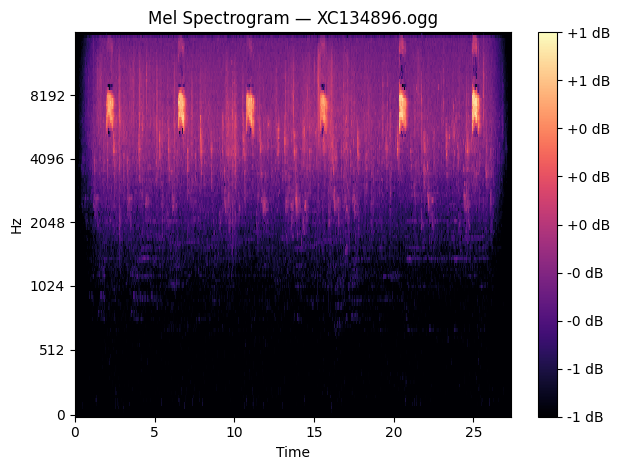

Showing spectrogram for: XC634242.ogg
(128, 698)


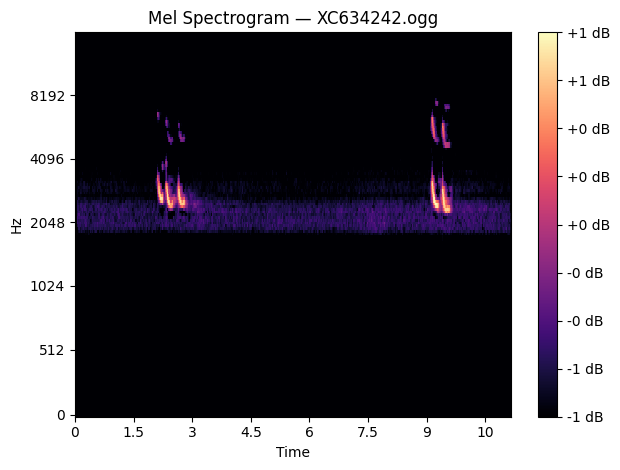

Showing spectrogram for: XC761056.ogg
(128, 913)


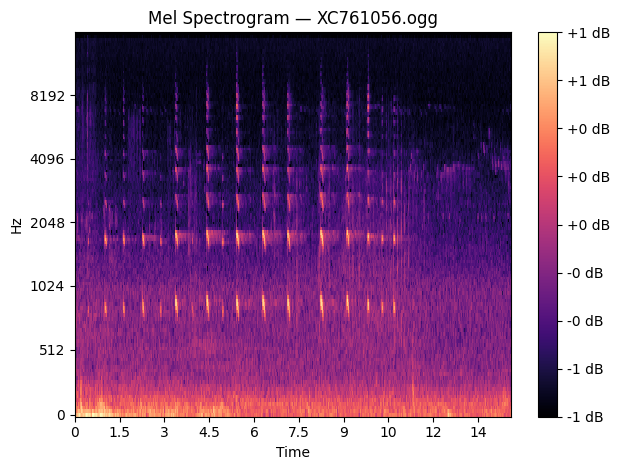

Showing spectrogram for: XC658167.ogg
(128, 632)


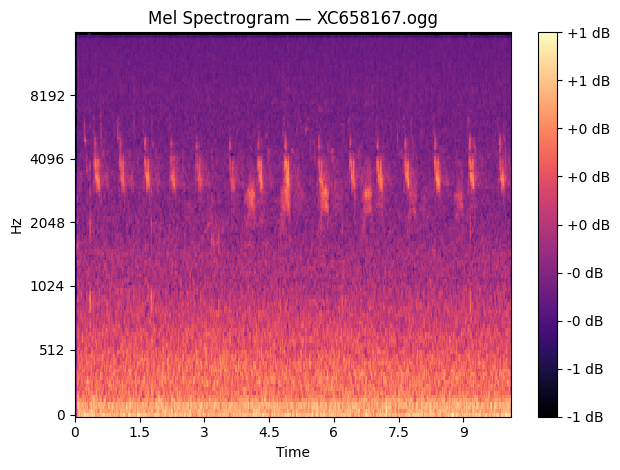

Showing spectrogram for: XC835050.ogg
(128, 551)


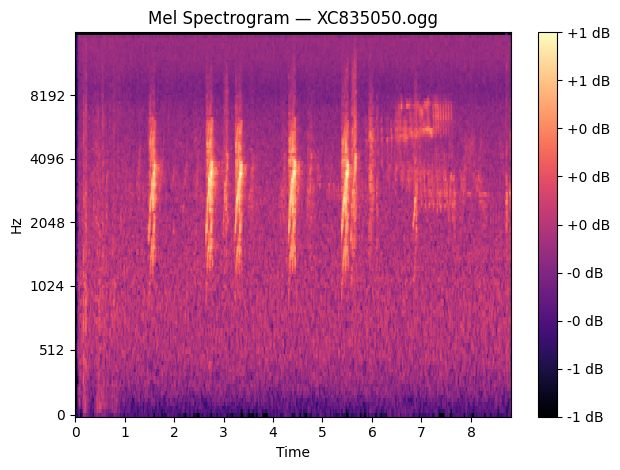

In [9]:
# Ensure plots display inline
%matplotlib inline

audio_dir = "train_audio"    # Your root audio directory
FREQUENCY = 16000

# Find all .ogg files recursively
audio_files = sorted(glob.glob(os.path.join(audio_dir, "**", "*.ogg"), recursive=True))

print(f"Found {len(audio_files)} .ogg files.")

# Show every 5000th spectrogram
for i, filepath in enumerate(audio_files):
    if i % 5000 == 0:
        filename = os.path.basename(filepath)
        show_audio(filename)

# Data preprocessing

### Filtering train metadata

In [10]:
train_metadata_filtered = train_metadata[["primary_label", "filename"]]
train_metadata_filtered


,primary_label,filename
0,asbfly,asbfly/XC134896.ogg
1,asbfly,asbfly/XC164848.ogg
2,asbfly,asbfly/XC175797.ogg
3,asbfly,asbfly/XC207738.ogg
4,asbfly,asbfly/XC209218.ogg
...,...,...
24454,zitcis1,zitcis1/XC845747.ogg
24455,zitcis1,zitcis1/XC845817.ogg
24456,zitcis1,zitcis1/XC856176.ogg
24457,zitcis1,zitcis1/XC856723.ogg


---
## Functions


Installing used audio augmentation package

In [11]:
!pip install --quiet audiomentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 23.3 MB/s eta 0:00:00


In [12]:
import os
import librosa
from tensorflow import keras
from tensorflow.keras import layers
import random

### Audio augmentation and split


In [13]:
# Audio augmentations (audiomentations)
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, OneOf, HighPassFilter, BandPassFilter, ClippingDistortion

audio_augmenter = Compose([
    OneOf([
        TimeStretch(
            min_rate=0.85,   # max ~15% slowing
            max_rate=1.15,   # max ~15% accelaration
            leave_length_unchanged=True,
            p=1.0
        ),
        PitchShift(
            min_semitones=-2.0,  # -2 half note
            max_semitones= 2.0,  # +2 half note
            p=1.0
        ),
    ], p=0.6),   # 60% of samples gets time or pitch augmentation

    # noise – simulating real environment
    AddGaussianNoise(
        min_amplitude=0.001,
        max_amplitude=0.015,
        p=0.4
    )
])

augmenter_nondup = Compose([
    OneOf([
        TimeStretch(min_rate=0.9, max_rate=1.1, leave_length_unchanged=True),
        PitchShift(min_semitones=-1.5, max_semitones=1.5),
    ], p=0.4),

    AddGaussianNoise(min_amplitude=0.0005, max_amplitude=0.008, p=0.3),

    # Clipping noise from audio
    OneOf([
        HighPassFilter(min_cutoff_freq=200, max_cutoff_freq=1200),
        BandPassFilter(min_center_freq=2000, max_center_freq=8000),
    ], p=0.2),

    ClippingDistortion(max_percentile_threshold=20, p=0.1),

])


augmenter_duplicate = Compose([
    OneOf([
        TimeStretch(min_rate=0.85, max_rate=1.15, leave_length_unchanged=True),
        PitchShift(min_semitones=-2, max_semitones=2),
    ], p=0.8),

    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.6),

    OneOf([
        HighPassFilter(min_cutoff_freq=150, max_cutoff_freq=1500),
        BandPassFilter(min_center_freq=1500, max_center_freq=9000),
    ], p=0.25),

    ClippingDistortion(max_percentile_threshold=30, p=0.2),

])


def apply_audio_augmentations(y, is_duplicate=False, sr=32000):
    if is_duplicate:
        return augmenter_duplicate(samples=y, sample_rate=sr)
    else:
        return augmenter_nondup(samples=y, sample_rate=sr)

In [14]:
fmin = 100 # minimum frequency
sr = 32000 # sampling rate
CHUNK_SIZE = 5.0 # audio chunk size
STEP = 4.0 # step size in splitting audio
CHUNK_LENGTH = 320

Loading audio and converting to spectogram (mel)

In [15]:
def load_audio(path, sr=32000, duration=None, offset=0.0):
    y, _ = librosa.load(path, sr=sr, mono=True, duration=duration, offset=offset)
    return y

def audio_to_mel(y, sr=32000, n_fft=2048, hop_length=512, n_mels=128, fmin=fmin, fmax=16000):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length,
                                         n_mels=n_mels, fmin=fmin, fmax=fmax)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # normalize to [-1, 1]
    mel_db_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min()) * 2.0 - 1.0
    return mel_db_norm.astype(np.float32)

Slicing audio into chunks, the splitted audios will have (window - step) overlay. We pad the end of the clips.

In [16]:
def slice_audio(y, sr, window, step):
    win_length = int(window * sr)
    step_length = int(step * sr)

    slices = []
    for start in range(0, max(1, len(y) - win_length + 1), step_length):
        end = start + win_length
        y_slice = y[start:end]

        # Padding if chunk is too short
        if len(y_slice) < win_length:
            y_slice = np.pad(y_slice, (0, win_length - len(y_slice)))

        slices.append(y_slice)
    return slices


Spectogram augmentation

In [17]:
# Spectrogram augmentations (SpecAugment) and random contrast

def spec_augment(mel, time_mask_param=10, freq_mask_param=4, num_time_masks=1, num_freq_masks=1):
    # mel: numpy array (n_mels, time_steps)
    m = mel.copy()
    n_mels, t = m.shape
    for _ in range(num_freq_masks):
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, n_mels - f + 1)
        m[f0:f0+f, :] = 0
    for _ in range(num_time_masks):
        tt = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, t - tt + 1)
        m[:, t0:t0+tt] = 0
    return m

def random_contrast(mel, lower=0.7, upper=1.3):
    factor = random.uniform(lower, upper)
    m = mel * factor
    # Clip to [-1,1] assuming input normalized to [-1,1]
    return np.clip(m, -1.0, 1.0)

# Creating the dataset to train the model

Creating the dataset by slicing audios to 5 second chunks with 4 second step. This way chunks will have overlays, so they don't lose correlation. We augment the data of classes with smaller instance numbers. We use generator to produce the dataset for the model.

In [18]:
from collections import defaultdict

# Example tf.data pipeline that yields mel-spectrogram patches and multi-label targets
AUTOTUNE = tf.data.AUTOTUNE


def make_dataset(filepaths, labels, batch_size=16, shuffle=True, augment=True):
    # filepaths: list of audio paths
    # labels: numpy array shape (N, num_classes) of 0/1
    def generator():
        print("start generator")

        # dictionarys where class indexes list of paths
        original_class_to_filepaths = defaultdict(list)  # if it's the first time
        duplicate_class_to_filepaths = defaultdict(list) # if they've been loaded already

        for fp, onehot in zip(filepaths, labels): # filling original_class_to_filepaths
            class_idx = np.argmax(onehot)  # index of the class
            original_class_to_filepaths[class_idx].append(fp)

        original_class_to_filepaths = dict(original_class_to_filepaths) # convert to dict

        # Number of classes: 182
        num_classes = len(train_metadata["primary_label"].unique())
        # Count how many chunks of each class we have loaded already
        chunk_counter = np.zeros((num_classes), dtype=np.float64)

        def get_next_filepath(idx): # idx: index of the required class
            # returns: (filepath, is_duplicate)

            if len(original_class_to_filepaths[idx]) != 0: # if there is data left to read
                filepath = random.choice(original_class_to_filepaths[idx]) # picking a file randomly
                original_class_to_filepaths[idx].remove(filepath) # remove from the not read ones
                duplicate_class_to_filepaths[idx].append(filepath) # add to duplicates
                return (filepath, False)

            # if only the duplicate is left:
            filepath = random.choice(duplicate_class_to_filepaths[idx]) # picking a file randomly
            return (filepath, True)

        # main loop
        while True:

            # index of the next class
            idx = chunk_counter.argmin()

            # calculating next file to load
            fp, is_duplicate = get_next_filepath(idx)

            # creating label for class
            label = np.zeros(num_classes, dtype=np.float32)
            label[idx] = 1.0

            # debug message
            if DEBUG:
                print("load", fp)

            # loading the audio file
            y = load_audio(fp, sr=sr)

            # splitting into chunks
            chunks = slice_audio(y, sr=sr, window=CHUNK_SIZE, step=STEP)

            # iterating through chunks
            for audio_chunk in chunks:

                if augment:
                    audio_chunk = apply_audio_augmentations(audio_chunk, sr=sr)

                # convert audio to spectogram
                mel = audio_to_mel(audio_chunk, sr=sr)

                if augment:
                    mel = spec_augment(mel)
                    mel = random_contrast(mel)

                mel_T = mel.T

                # fix time dimension
                target_time = CHUNK_LENGTH
                if mel_T.shape[0] < target_time:
                    mel_T = np.pad(mel_T, ((0, target_time - mel_T.shape[0]), (0,0)))
                else:
                    mel_T = mel_T[:target_time]

                img = np.expand_dims(mel_T, -1).astype(np.float32)

                # increase counter
                chunk_counter += label

                yield img, label


    output_signature = (
        tf.TensorSpec(shape=(None, 128, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(labels.shape[1],), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(generator, output_signature=output_signature)


    if shuffle:
        ds = ds.shuffle(1024, seed=SEED)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# Cross validation

Collecting all file paths and labeling classes by primary label. We use one-hot encoding.


In [19]:
from sklearn.model_selection import StratifiedKFold

STRATIFIED = True
N_FOLDS = 5

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=False)#, random_state=SEED)

# Store fold indices
fold_splits = []
#all_val_indices = []

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(train_metadata_filtered, train_metadata_filtered['primary_label'] if STRATIFIED else None)):
    fold_splits.append({
        'fold_idx': fold_idx + 1,
        'train_idx': train_idx.copy(),
        'val_idx': val_idx.copy(),
        'train_size': len(train_idx),
        'val_size': len(val_idx)
    })

    #all_val_indices.extend(val_idx.tolist())

    # Verify no overlap between train and val within same fold
    #overlap = set(train_idx) & set(val_idx)
    #assert len(overlap) == 0, f"Fold {fold_idx+1}: Train/Val overlap detected! ({len(overlap)} samples)"

    print(f"  Fold {fold_idx + 1}: Train={len(train_idx)}, Val={len(val_idx)}")

    # Show first 5 validation indices for this fold (for verification)
    print(f"    First 5 val indices: {val_idx[:5].tolist()}")

  Fold 1: Train=19567, Val=4892
    First 5 val indices: [0, 1, 2, 3, 4]
  Fold 2: Train=19567, Val=4892
    First 5 val indices: [21, 22, 23, 24, 25]
  Fold 3: Train=19567, Val=4892
    First 5 val indices: [42, 43, 44, 45, 46]
  Fold 4: Train=19567, Val=4892
    First 5 val indices: [63, 64, 65, 66, 67]
  Fold 5: Train=19568, Val=4891
    First 5 val indices: [84, 85, 86, 87, 88]


In [20]:
from sklearn.preprocessing import LabelEncoder

AUDIO_BASE = "./train_audio"

# filepaths
filepaths = [
    os.path.join(AUDIO_BASE, fp)
    for fp in train_metadata['filename'].values
]

# label encoding
le = LabelEncoder()
integer_labels = le.fit_transform(train_metadata_filtered['primary_label'])

num_classes = len(le.classes_)
labels_onehot = np.zeros((len(integer_labels), num_classes), dtype=np.float32)
labels_onehot[np.arange(len(integer_labels)), integer_labels] = 1.0

x_data = np.array(filepaths)
y_data = np.array(labels_onehot)

# Displaying the distribution of chunk numbers by class

Distribution of chunks. We can't view the distribution without reading all the files, so we saved it here.

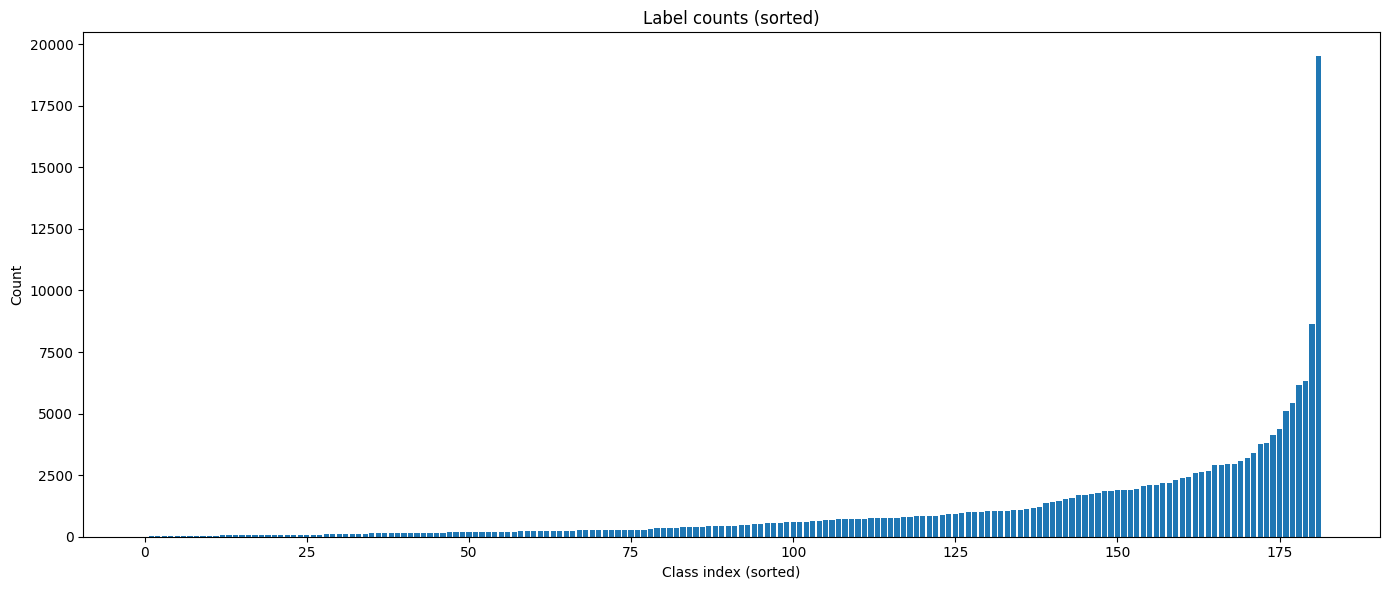

In [22]:
result = np.array([  823,   881,   609,   288,  1876,    12,   105,   136,   602,
        3776,  3382,   175,    89,  2082,  4111,  1135,    25,  1795,
         962,   908, 19508,    40,   194,    70,   716,   188,  1002,
        1057,  1072,    67,   837,   332,   195,  1917,    68,   722,
         147,  2665,  1567,  2900,  2171,  6144,   266,  5092,  2422,
        1841,   746,   150,   533,    77,  1031,    91,    19,  2951,
         439,  4390,   131,  2574,   379,   692,   426,   449,  3814,
         253,   996,  1098,   283,   249,   448,   244,  6306,  2390,
        1209,  2200,   213,    96,  3064,   764,  1707,   149,  5437,
         805,  8650,   670,   406,   262,   179,    82,   429,    25,
         493,   245,    15,    70,   126,   651,    75,   368,  1025,
          81,  1685,   763,   573,   211,   176,  3195,  1941,  2301,
         726,   924,   164,   266,   127,    74,    55,   371,   377,
         146,    46,     8,   707,   258,   349,   277,    62,   634,
         590,   254,    66,  1006,   183,    24,  1385,   366,   759,
         190,  1912,    56,  1462,   851,  2085,   762,  1392,  2965,
         566,   114,   798,   226,    45,   229,    40,   565,    74,
         495,   289,  1186,   174,   166,   855,   130,  1726,   722,
         156,   185,   133,    30,  2049,   227,   618,   165,   286,
        1546,   506,   240,  1908,   380,  1027,  2647,    72,   156,
         223,  2927])

sorted_idx = np.argsort(result)   # ascending
# sorted_idx = np.argsort(-label_counts)  # descending

sorted_counts = result[sorted_idx]

plt.figure(figsize=(14, 6))
plt.bar(range(len(sorted_counts)), sorted_counts)
plt.title("Label counts (sorted)")
plt.xlabel("Class index (sorted)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Model

In [23]:
# Imports
from tensorflow.keras.layers import (
    Conv2D, DepthwiseConv2D, BatchNormalization,
    ReLU, GlobalAveragePooling2D, Dense, Input
)
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

from tensorflow.keras.models import Model

In [24]:
IMG_SIZE = (320, 128) # Size of one spectogram chunk
BATCH_SIZE = 128
num_species = len(train_metadata['primary_label'].value_counts())
BASE_DIR="/content"

In this function we create the model with ResNet50 architekture + classification head using fully-connected layers

In [25]:
def create_model():
  # Define an input layer that matches the 1-channel spectrograms
  inputs = keras.Input(shape=(*IMG_SIZE, 1))

  # Convert the 1-channel input to 3 channels by repeating the single channel
  # Wrapped tf.repeat in a Lambda layer to operate on KerasTensor
  x = layers.Lambda(lambda x: tf.repeat(x, repeats=3, axis=-1))(inputs)

  base_model = keras.applications.ResNet50(
    include_top=False,
    input_tensor=x, # Pass the 3-channel input to the base model
    pooling="avg"
  )

  # train the entire model
  base_model.trainable = True

  x = layers.Dense(256, activation="relu")(base_model.output)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(0.5)(x)

  outputs = layers.Dense(num_species, activation="softmax")(x)

  # Create the model with the original 1-channel input and the new outputs
  model = models.Model(inputs=inputs, outputs=outputs)

  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=0.05),
      loss=tf.keras.losses.CategoricalCrossentropy(), # Changed to CategoricalCrossentropy for one-hot labels
      metrics=["accuracy"]
  )

  return model

## Creating and training model

We use cross-validation (KFold) to validate our model. We use the following callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau. We print scores using multiple metrics to measure our model's precision.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

EPOCHS = 3
scores = []

for fold in fold_splits:
    print("Starting fold ", fold['fold_idx'])

    train_x = x_data[fold['train_idx']]
    train_y = y_data[fold['train_idx']]

    valid_x = x_data[fold['val_idx']]
    valid_y = y_data[fold['val_idx']]

    ds_train = make_dataset(
        train_x,
        train_y,
        batch_size=128,
        augment=True,
        shuffle=True
    )

    ds_valid = make_dataset(
        valid_x,
        valid_y,
        batch_size=128,
        augment=False,
        shuffle=True
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )

    model_checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=f'best_model_stage_I_Fold_{fold['fold_idx']}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    # Fix: Pass the correct input_shape to match the dataset output
    model = create_model()

    # Summary
    print(f"\n📋 Model information:")
    print(f"   - Layers: {len(model.layers)}")
    print(f"   - Input shape: {model.input_shape}")
    print(f"   - Output shape: {model.output_shape}")
    print(f"   - Trainable: {model.count_params()}")

    history = model.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS,
        callbacks=[early_stopping, model_checkpoint, reduce_lr],
        verbose=1,
        steps_per_epoch=100,
        validation_steps=50

    )

    # Evaluate
    val_loss, val_acc = model.evaluate(ds_valid, verbose=0)
    print(f"Validation Accuracy: {val_acc:.4f}")
    scores.append(val_acc)

    # Extra evaluation metrics on the validation set

    y_true_list = []
    y_pred_list = []


    all_valid_x = []
    all_valid_y = []


    for batch_x, batch_y in ds_valid:
        y_true_list.append(batch_y.numpy())
        y_pred_list.append(model.predict(batch_x, verbose=0))

        if len(y_true_list) * BATCH_SIZE >= len(valid_x): # Approximate stopping condition
             break

    y_true = np.concatenate(y_true_list, axis=0)
    y_pred = np.concatenate(y_pred_list, axis=0)

    # Binarize predictions with a 0.5 threshold (multi-label)
    y_pred_bin = (y_pred >= 0.5).astype(int)

    macro_f1 = f1_score(y_true, y_pred_bin, average="macro", zero_division=0)
    micro_f1 = f1_score(y_true, y_pred_bin, average="micro", zero_division=0)
    macro_precision = precision_score(y_true, y_pred_bin, average="macro", zero_division=0)
    macro_recall = recall_score(y_true, y_pred_bin, average="macro", zero_division=0)
    mAP = average_precision_score(y_true, y_pred, average="macro")

    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Micro F1: {micro_f1:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall: {macro_recall:.4f}")
    print(f"Mean Average Precision (mAP): {mAP:.4f}")


print("All fold accuracies:", scores)
print("Mean accuracy:", sum(scores)/len(scores))

Starting fold  1

📋 Model information:
   - Layers: 181
   - Input shape: (None, 320, 128, 1)
   - Output shape: (None, 182)
   - Trainable: 24160054
Epoch 1/3
start generator
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0673 - loss: 5.9974start generator

Epoch 1: val_accuracy improved from -inf to 0.00313, saving model to best_model_stage_I_Fold_1.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 743s 7s/step - accuracy: 0.0672 - loss: 5.9950 - val_accuracy: 0.0031 - val_loss: 5.4630 - learning_rate: 0.0500
Epoch 2/3
 46/100 ━━━━━━━━━━━━━━━━━━━━ 4:21 5s/step - accuracy: 0.0160 - loss: 5.5242

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

EPOCHS = 1
n_fold = 3
scores = []

for i in range(n_fold):
  train_dataset, val_dataset = make_dataset(
      filepaths,
      labels_onehot,
      batch_size=BATCH_SIZE,
      augment=True,
      shuffle=False,
      validation_rate=n_fold,
      fold=i
  )

  early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
  )

  model_checkpoint = keras.callbacks.ModelCheckpoint(
      filepath=f'best_model_stage_I_Fold_{i}.keras',
      monitor='val_accuracy',
      save_best_only=True,
      verbose=1
  )

  reduce_lr = keras.callbacks.ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.3,
      patience=3,
      min_lr=1e-6,
      verbose=1
  )

  model = create_model()

  # Summary
  print(f"\n📋 Model information:")
  print(f"   - Layers: {len(model.layers)}")
  print(f"   - Input shape: {model.input_shape}")
  print(f"   - Output shape: {model.output_shape}")
  print(f"   - Trainable: {model.count_params()}")

  history = model.fit(
      train_dataset,
      validation_data=val_dataset,
      epochs=EPOCHS,
      callbacks=[early_stopping, model_checkpoint, reduce_lr],
      verbose=1
  )

  # Evaluate
  val_loss, val_acc = model.evaluate(val_dataset, verbose=0)
  print(f"Validation Accuracy: {val_acc:.4f}")
  scores.append(val_acc)

  # Extra evaluation metrics on the validation set

  y_true_list = []
  y_pred_list = []

  for batch_x, batch_y in val_dataset:
      y_true_list.append(batch_y.numpy())
      y_pred_list.append(model.predict(batch_x, verbose=0))

  y_true = np.concatenate(y_true_list, axis=0)
  y_pred = np.concatenate(y_pred_list, axis=0)

  # Binarize predictions with a 0.5 threshold (multi-label)
  y_pred_bin = (y_pred >= 0.5).astype(int)

  macro_f1 = f1_score(y_true, y_pred_bin, average="macro", zero_division=0)
  micro_f1 = f1_score(y_true, y_pred_bin, average="micro", zero_division=0)
  macro_precision = precision_score(y_true, y_pred_bin, average="macro", zero_division=0)
  macro_recall = recall_score(y_true, y_pred_bin, average="macro", zero_division=0)
  mAP = average_precision_score(y_true, y_pred, average="macro")

  print(f"Macro F1: {macro_f1:.4f}")
  print(f"Micro F1: {micro_f1:.4f}")
  print(f"Macro Precision: {macro_precision:.4f}")
  print(f"Macro Recall: {macro_recall:.4f}")
  print(f"Mean Average Precision (mAP): {mAP:.4f}")


print("All fold accuracies:", scores)
print("Mean accuracy:", sum(scores)/len(scores))